# Monte Carlo Simulation (GBM) of a Portfolio

### Import relevant modules

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import yfinance as yf
import scipy

### Import closed prices of stocks from Yahoo Finance

Fetched todays date and assigned to variable `end_date` with function `datetime.today()`. Calculated the date one year in the past, `start_date`, with `timedelta(days)`.

Created a dataframe to hold the histroical prices of the porfolio with pandas function `pd.DataFrame()`.

In [50]:
pfolio_prices_df = pd.DataFrame()  

In [51]:
tickers = ['AAPL','JPM','PFE','XOM'] #1-D array containing name of stocks to import histrocial prices of

In [52]:
end_date = datetime.today() #today's date 
start_date = end_date - timedelta(days = 5*365) #date two year ago today

Used yfinance function `yf.download(ticker, start, end)` to import histroical data from Yahoo Finance.

In [53]:
for ticker in tickers:
    data = yf.download(ticker, start = start_date, end = end_date) 
    pfolio_prices_df[ticker] = data['Close']

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Checked dataframe has been created as expected using `.head()`.

In [54]:
pfolio_prices_df.head()

,AAPL,JPM,PFE,XOM
Date,,,,
2021-09-14,144.471970,138.599579,34.315868,45.805019
2021-09-15,145.359558,139.561356,34.361912,47.349190
2021-09-16,145.125458,139.499603,34.131660,46.845661
2021-09-17,142.462692,139.137802,33.686501,46.291767
2021-09-20,139.419571,134.972885,33.924427,45.058109


Selected only last row with `.iloc[-1]` which corresponds to the current price of the stocks, assigned to a seperate dataframe.~ 

In [55]:
pfolio_prices_today_df = pfolio_prices_df.iloc[-1] 
pfolio_prices_today_df

AAPL    332.269989
JPM     356.230011
PFE      27.719999
XOM     165.990005
Name: 2026-09-11 00:00:00, dtype: float64

## Geometric Brownian Motion engine (GBM using Ito's Lemma)

The stochastic differential equation used to model time-evolution of a price $S(t)$;
$$ dS(t) = \mu S(t)dt + \sigma S(t)dB(t) $$
where $\mu$ is the drift, $\sigma$ is the volaility.

The solution to $S(t)$ can be found by applying Ito's Lemma [1]. Divide through by $S(t)$; 
$$ \frac{dS(t)}{S(t)} = \mu dt + \sigma dB(t) $$
The right hand sides form is similar to the derivative of $log(S(t))$, applying Ito's Lemma to $log(S(t))$;
$$ d(log(S(t))) = (log(S(t)))' \mu S(t)dt + (log(S(t)))'\sigma S(t)dB(t) + \frac{1}{2}(log(S(t)))'' \sigma^{2} S(t)^{2} dt $$
This gives; 
$$ d(log(S(t))) = \mu dt + \sigma dB(t) - \frac{1}{2}\sigma^{2}dt = (\mu - \frac{1}{2}\sigma^{2})dt + \sigma dB(t) $$
This is an Ito drift-diffusion process which is a standard Brownian motion with a drift term. This formulae is an integral formulae so;
$$ log(\frac{S(t)}{S(0)}) = (\mu - \frac{1}{2}\sigma^{2})dt + \sigma dB(t) $$
where the log daily return, $R = log(\frac{S(t)}{S(0)})$
This can also be expressed exponentially;
$$ S(t) = S(0)exp((\mu - \frac{1}{2}\sigma^{2})dt + \sigma dB(t))$$

### Calculate the Drift (Mean Daily Returns) and Volatility (Standard Deviation) of each stock

Created a dataframe to hold the histroical log daily returns of the porfolio with pandas function `pd.DataFrame()`. Calculated the daily returns with `pct.change`; 

In [56]:
pfolio_returns_df = pd.DataFrame()
for ticker in tickers:
    pfolio_returns_df[ticker] = np.log(pfolio_prices_df[ticker].pct_change() + 1) 

In [57]:
pfolio_returns_df = pfolio_returns_df.dropna() #remove the NaN from the first row

In [58]:
pfolio_returns_df.head() #check dataframe is created as expected

,AAPL,JPM,PFE,XOM
Date,,,,
2021-09-15,0.006125,0.006915,0.001341,0.033156
2021-09-16,-0.001612,-0.000443,-0.006723,-0.010691
2021-09-17,-0.018518,-0.002597,-0.013128,-0.011894
2021-09-20,-0.021592,-0.030391,0.007038,-0.027011
2021-09-21,0.003422,0.000131,-0.006355,-0.000932


### Correlation and Covariance Matrix For Assets In Portfolio

Calculated the correlation matrix by applying `.corr()` to the dataframe holding the log returns. Applied a Cholesky decompostion [2] to the correlation matrix, to produce a matrix to correlate a random normal distribution;

In [59]:
correlation = pfolio_returns_df.corr() #correlation matrix
L =  np.linalg.cholesky(correlation) #Cholesky Decomposition of correlation matrix

In [60]:
cov = pfolio_returns_df.cov() *252 #annualised

### Parameters of Portfolio (Initial value, Assets weighting)

In [61]:
pfolio_val = 10000 #initial portfolio value
invested_per = pfolio_val / len(tickers)
weighting = np.array([1/len(tickers)]* len(tickers)) #1D array holding assets weighting

### Geometric Brownian Motion Function

In [62]:
steps_per_annum = 252 #number of trading days per year 
n_years = 2 #number of future years to simulate 
dt = 1/steps_per_annum
n_steps = n_years * steps_per_annum #number of days in those two simulated years
n_paths = 10000 #number of price paths to simulate


In [63]:
def gbm(ticker, dt, n_steps):
    mean_return = np.average(pfolio_returns_df[ticker]) *252  #annualised drift
    std_return = np.std(pfolio_returns_df[ticker]) * np.sqrt(252) #annualised volatility
    
    Z = np.random.normal(loc=0.0, scale=1.0, size = (len(tickers), n_steps * n_paths)) #uncorrelated random shocks

    B = np.dot(L,Z)

    B = B.reshape(len(tickers), n_steps, n_paths) #correlated random shocks [2]

    return (mean_return-(std_return**2)/2)*dt + std_return*np.sqrt(dt)*B #the simulated returns S(t) for the future two years 
    

## Correlated Simulated Paths For Each Asset

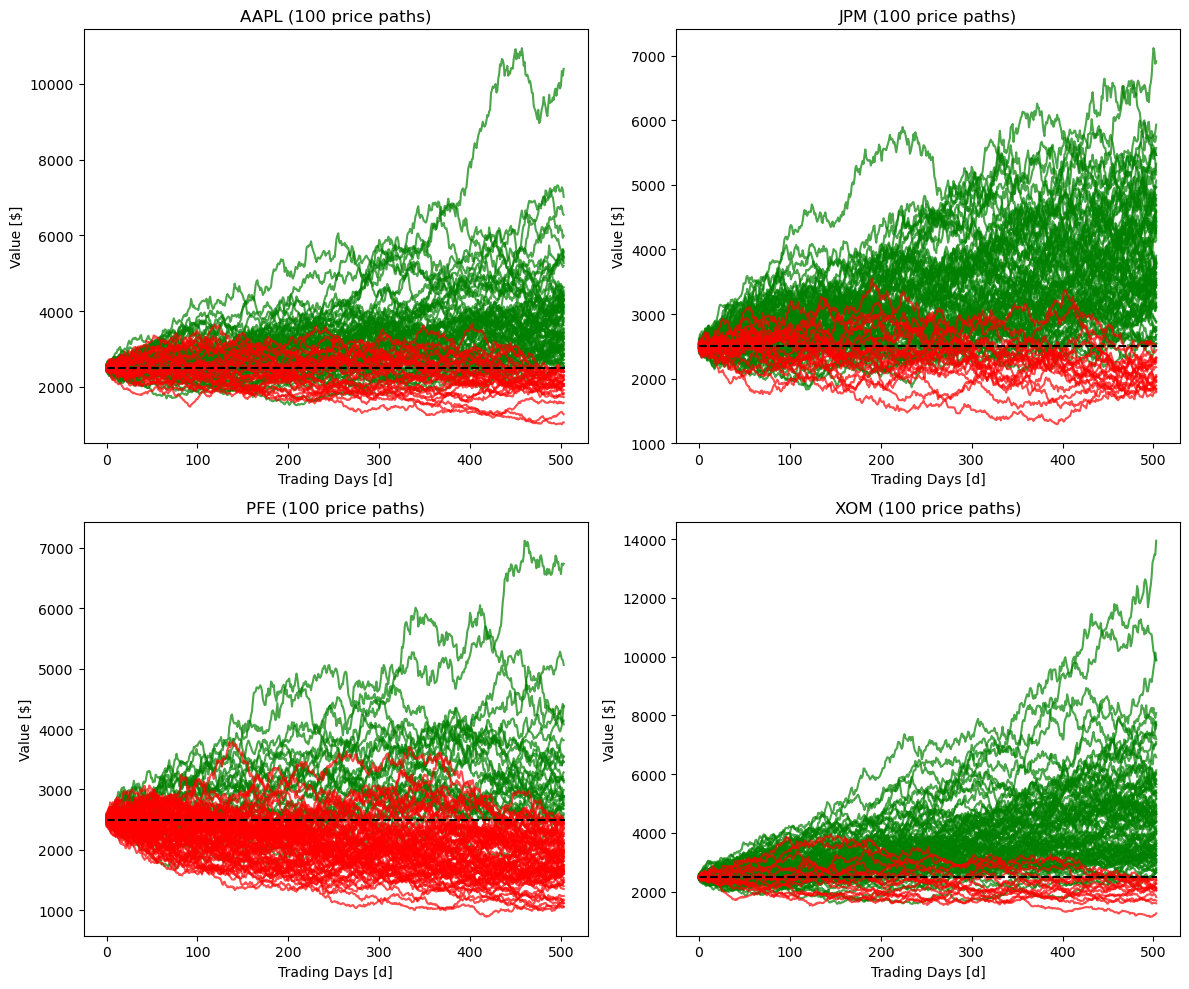

In [64]:
pfolio_R_dfs = {}  #dictionary holding simulated returns
pfolio_vals_dfs = {} #dictionary holding simulated values calculated from returns

fig = plt.figure(figsize=(12, 10))

for i, ticker in enumerate(tickers):
    R = gbm(ticker , dt, n_steps)
    pfolio_R_dfs[ticker] = pd.DataFrame(R[i,:,:])
    pfolio_vals_dfs[ticker] = invested_per *np.exp(pfolio_R_dfs[ticker].cumsum())  #convert returns into values of the portfolio

    sample = pfolio_vals_dfs[ticker].iloc[:, :100]  #create a sample of first 100 price paths to plot
    pnl = sample.iloc[-1] - invested_per #calculate the profit or loss for every price paths
    profit = pnl > 0 #mask for shape of last row of price paths which are profitable
    loss = pnl <= 0 #for loss

    
    fig.add_subplot(2,2, i+1)
    plt.plot(sample.loc[:, profit], color = 'green', alpha = 0.7); #profiable price paths
    plt.plot(sample.loc[:,loss], color = 'red', alpha = 0.7) #losing price paths
    plt.hlines(y=invested_per, ls = '--', color = 'k', xmin = 0, xmax = n_steps) #initial Asset value
    
    plt.xlabel('Trading Days [d]')
    plt.ylabel('Value [$]')
    plt.title(ticker + ' (100 price paths)')
plt.tight_layout()
plt.show()


## Portfolio Value

In [65]:
val_data = sum(pfolio_vals_dfs.values()) #sum induvidual values of each stock within portfolio after every trading day
pfolio_vals_dfs['Portfolio Value'] = pd.DataFrame(val_data)
pfolio_vals_dfs['Portfolio Value'].head() #check dataframe is as expected 

R_data = sum(pfolio_R_dfs.values()) #sum induvidual values of each stock within portfolio after every trading day
pfolio_R_dfs['Portfolio Returns'] = pd.DataFrame(R_data)
pfolio_R_dfs['Portfolio Returns'].head() #check dataframe is as expected 

pfolio_final_vals_df = np.array(pfolio_vals_dfs['Portfolio Value'].iloc[-1]) #isolate the last row representing final portfolio values

### Calculating Risk Metrics (Sharpe ratio, VaR, CVaR and Probability of Loss)

In [66]:
risk_free_rate = 0.02
daily_risk_free_rate = risk_free_rate / 252

pfolio_simple_returns = pfolio_vals_dfs['Portfolio Value'].pct_change().dropna()

sharpe_per_path = ((np.mean(pfolio_simple_returns, axis = 0) - daily_risk_free_rate) /np.std(pfolio_simple_returns, axis = 0))*np.sqrt(252)

sharpe = np.mean(sharpe_per_path)


In [67]:
cumulative_max = np.maximum.accumulate(pfolio_vals_dfs['Portfolio Value'], axis = 0)
max_drawdown_per_path = ((pfolio_vals_dfs['Portfolio Value'] - cumulative_max)/ cumulative_max).min(axis = 0)

mean_max_drawdown = np.mean(max_drawdown_per_path)
worst_max_drawdown = max_drawdown_per_path.min()

In [68]:
confidence_lvl = 0.95 #VaR 
cutoff_percentile = (1-confidence_lvl)*100 #For 5th percentile

cash_risk = np.percentile(pfolio_final_vals_df, cutoff_percentile)

var = cash_risk - pfolio_val

var_percentage = (var/pfolio_val)*100 #var as % of initial portfolio value


extreme_confidence_lvl = 0.99 #Extreme case
extreme_cutoff_percentile = (1-extreme_confidence_lvl)*100 #1st percentile

extreme_cash_risk = np.percentile(pfolio_final_vals_df, extreme_cutoff_percentile)

extreme_var = extreme_cash_risk - pfolio_val

extreme_var_percentage = (extreme_var/pfolio_val)*100 #var as % of initial portfolio value

In [69]:
cvar = (pfolio_final_vals_df[pfolio_final_vals_df <= cash_risk]).mean() - pfolio_val #The mean of cash loss in 5th cumelative tail

cvar_percentage = (cvar/pfolio_val)*100 


In [70]:
ProbLoss = (pfolio_final_vals_df < pfolio_val).mean() * 100 #Probability of Loss, .mean() treats losing (true) as 0 and profit (false) as 1

In [71]:
best_confidence_lvl = 0.05
best_cutoff_percentile = (1-best_confidence_lvl)*100 #95th percentile

cash_best = np.percentile(pfolio_final_vals_df, best_cutoff_percentile)

best_case = cash_best - pfolio_val

best_cash_percentage = (best_case/pfolio_val)*100

mean_pfolio_val = pfolio_final_vals_df.mean() #average final portfolio value

### Simulated Paths of Portfolio Value

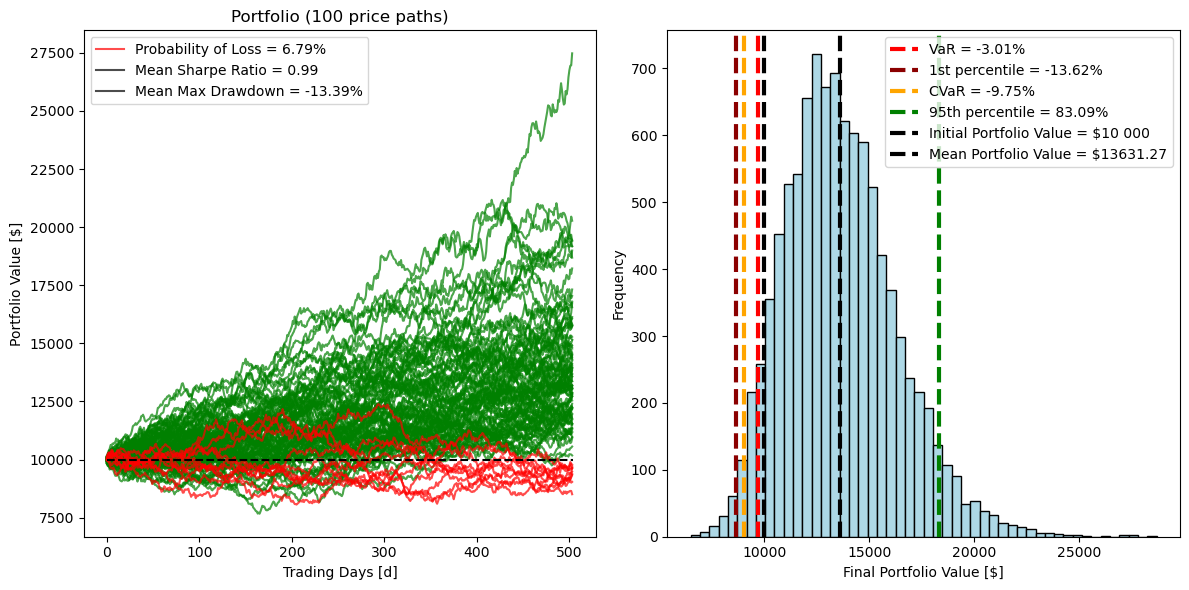

In [72]:
fig2 = plt.figure(figsize = (12,6))

#100 SIMULATED PRICE PATHS PLOTTED
fig2.add_subplot(1,2,1)

sample = pfolio_vals_dfs['Portfolio Value'].iloc[:, :100] #first 100 paths to plot
pnl = sample.iloc[-1] - pfolio_val 
profit = pnl > 0
loss = pnl <= 0

plt.plot(sample.loc[:, profit], color = 'green', alpha = 0.7); #profitable paths as green
plt.plot(sample.loc[:,loss], color = 'red', alpha = 0.7) #losing paths as red

plt.plot([], [], color = 'red', alpha = 0.7, label = f'Probability of Loss = {ProbLoss:.2f}%') #adds probability of loss onto legend
plt.plot([], [], color = 'k', alpha = 0.7, label = f'Mean Sharpe Ratio = {sharpe:.2f}') #adds sharpe ratio onto legend
plt.plot([], [], color = 'k', alpha = 0.7, label = f'Mean Max Drawdown = {mean_max_drawdown*100:.2f}%') #adds probability of loss onto legend

plt.hlines(y=pfolio_val, ls = '--', color = 'k', xmin = 0, xmax = n_steps) #intitial portfolio value

plt.xlabel('Trading Days [d]')
plt.ylabel('Portfolio Value [$]')
plt.title('Portfolio (100 price paths)')
plt.legend()


#DISTRIBUTION OF FINAL PORTFOLIO VALUES
bins = 50
z = np.linspace(pfolio_final_vals_df.min(), pfolio_final_vals_df.max(), 1000) #dummy z-values
binwidth = (pfolio_final_vals_df.max() - pfolio_final_vals_df.min())/bins

fig2.add_subplot(1,2,2)

#plt.plot(z, (scipy.stats.norm.pdf(loc = pfolio_final_vals_df.mean(),
       #scale = np.std(pfolio_final_vals_df), x = z)) * binwidth * len(pfolio_final_vals_df), color = 'k') #plots the normal distribution over histogram


plt.hist(pfolio_final_vals_df, bins, edgecolor = 'black', color = 'lightblue'); #histogram of final values distribution

#key values added to legend
plt.axvline(cash_risk, color = 'red', ls = '--', lw = 3, label = f'VaR = {var_percentage:.2f}%') #VaR
plt.axvline(extreme_cash_risk, color = 'darkred',ls = '--', lw = 3, label = f'1st percentile = {extreme_var_percentage:.2f}%') #extreme case of VaR
plt.axvline(cvar + pfolio_val, color = 'orange',ls = '--', lw = 3, label = f'CVaR = {cvar_percentage:.2f}%') #CVaR
plt.axvline(cash_best, color = 'green', lw = 3,ls = '--', label = f'95th percentile = {best_cash_percentage:.2f}%') #Best case scenario
plt.axvline(pfolio_val, color = 'black', lw = 3,ls = '--', label = 'Initial Portfolio Value = $10 000') #initial portfolio value
plt.axvline(mean_pfolio_val, color = 'black', lw = 3,ls = '--', label = f'Mean Portfolio Value = ${mean_pfolio_val:.2f}') #Mean of final portfolio values
 
plt.xlabel('Final Portfolio Value [$]')
plt.ylabel('Frequency')

plt.tight_layout()
plt.legend()
plt.show(fig2)



### Heatmap Of Correlation Between Assets

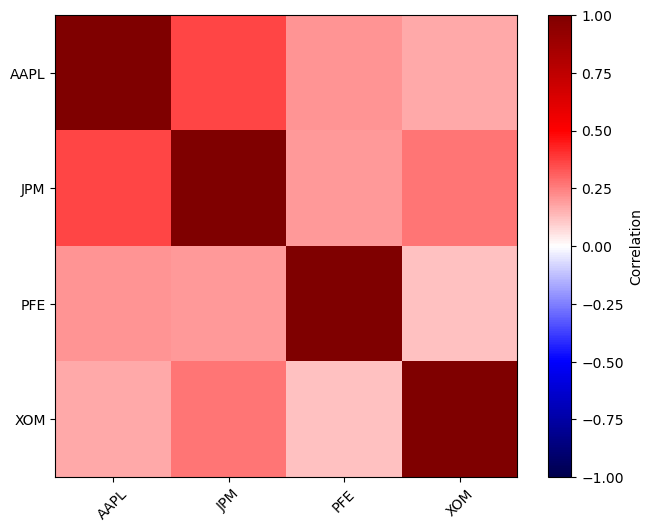

In [73]:
fig, ax = plt.subplots(figsize = (8,6))
im = ax.imshow(correlation, cmap = 'seismic', vmin = -1, vmax = 1)

ax.set_xticks(range(len(correlation.columns)))
ax.set_yticks(range(len(correlation.columns)))

ax.set_xticklabels(correlation.columns, rotation = 45)
ax.set_yticklabels(correlation.columns)

plt.colorbar(im, label = 'Correlation');

### Comparison Of Histoircal And Simulated Daily Log Returns

In [74]:
pfolio_returns_df['Portfolio Returns'] = pfolio_returns_df.dot(weighting)
historical_skew = scipy.stats.skew(pfolio_returns_df['Portfolio Returns'])
skew = scipy.stats.skew(pfolio_R_dfs['Portfolio Returns'].stack())
historical_kurtosis = scipy.stats.kurtosis(pfolio_returns_df['Portfolio Returns'])
kurtosis = scipy.stats.kurtosis(pfolio_R_dfs['Portfolio Returns'].stack())

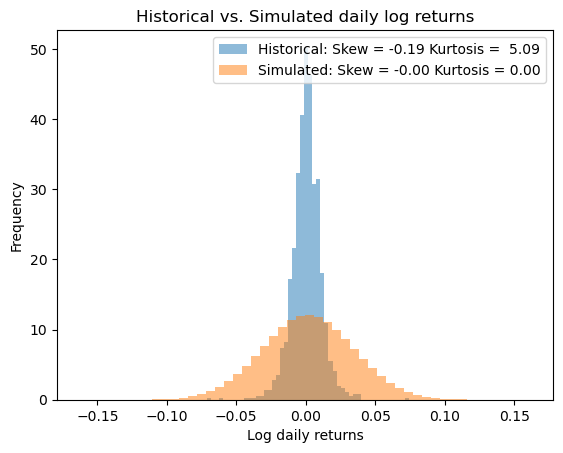

In [75]:
plt.hist(pfolio_returns_df['Portfolio Returns'], bins = 50, alpha = 0.5, density = 'true',
         label = F'Historical: Skew = {historical_skew: .2f} Kurtosis = {historical_kurtosis: .2f}');
plt.hist(pfolio_R_dfs['Portfolio Returns'].stack(), bins = 50, alpha = 0.5, density = 'true',
         label = F'Simulated: Skew = {skew:.2f} Kurtosis = {kurtosis:.2f}');
plt.legend()
plt.title('Historical vs. Simulated daily log returns')
plt.ylabel('Frequency')
plt.xlabel('Log daily returns')

## References

[1] QuarkGluon Ltd, 2016. Geometric Brownian Motion [Online]. Available from: https://www.quantstart.com/articles/Geometric-Brownian-Motion/ [Accessed 12 August 2026].

[2] Paolucci, R. Simulating Correlated Brownian Motions [Online]. ReadMedium. Available from: https://readmedium.com/simulating-correlated-brownian-motions-2fcdeaa546a0 [Accessed 13 September 2026]